# Opentron OT-2 Robot Control and Image Processing Tutorial

## Overview
This Jupyter notebook provides a comprehensive tutorial for undergraduate students to learn how to use the Opentron OT-2 liquid handling robot. The tutorial covers:

1. **Basic Opentron Concepts**: Understanding labware, pipettes, and protocol structure
2. **Robot Connectivity**: How to connect and communicate with the OT-2 robot
3. **Protocol Development**: Creating and uploading Python protocols
4. **Real-time Monitoring**: Tracking protocol execution and liquid handling operations
5. **Image Processing**: Using the built-in camera for automated image capture and analysis
6. **Data Analysis**: Processing ROI (Region of Interest) data for quantitative analysis

## What is the Opentron OT-2?
The Opentron OT-2 is an open-source liquid handling robot designed for laboratory automation. It can:
- Pipette liquids with high precision (0.5-1000 μL)
- Work with standard lab equipment (tips, plates, tubes)
- Execute complex protocols automatically
- Capture images during experiments for analysis

## Learning Objectives
By the end of this tutorial, you will understand how to:
- Set up communication with the OT-2 robot
- Define labware and pipette configurations
- Write and upload protocols to the robot
- Monitor protocol execution in real-time
- Process images captured during experiments
- Analyze experimental data using Python

---


# --- 1st Half --

## Part 1: Basic Opentron Concepts

### Understanding Opentron Components

Before we start programming the robot, let's understand the key concepts:

#### 1. **Labware**
Labware refers to the physical containers used in experiments:
- **96-well plates**: Standard microplates with 96 wells (8 rows × 12 columns)
- **Tip racks**: Hold pipette tips for the robot to pick up
- **Tubes and reservoirs**: For reagent storage
- **Custom labware**: Can be defined for specialized containers

#### 2. **Pipettes**
The OT-2 uses electronic pipettes that can be programmed:
- **P20 Single**: 0.5-20 μL (single channel)
- **P300 Single**: 20-300 μL (single channel)
- **P1000 Single**: 100-1000 μL (single channel)
- **P20 Multi**: 0.5-20 μL (8 channels for plate columns)
- **P300 Multi**: 20-300 μL (8 channels for plate columns)

#### 3. **Well Naming Convention**
Wells are named using row letters (A-H) and column numbers (1-12):
- `A1` = Top-left corner
- `H12` = Bottom-right corner
- Rows: A, B, C, D, E, F, G, H (top to bottom)
- Columns: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 (left to right)

---


## Part 2: Robot Connectivity and Setup

### Understanding the HTTP API
The Opentron OT-2 robot runs a web server that accepts HTTP requests for remote control. This allows us to:
- Check robot status and health
- Upload and manage protocols
- Start and monitor protocol execution
- Capture images from the built-in camera

### Connection Parameters
- **ROBOT_IP**: The IP address of your OT-2 robot on the network
- **BASE_URL**: The complete URL for API requests (http://ROBOT_IP:31950)
- **HEADERS**: Required headers for API compatibility

### What This Code Does:
1. **Defines connection parameters** for your specific robot
2. **Tests connectivity** by making a health check request
3. **Displays robot information** including model, software versions, and capabilities

💡 **Note**: Make sure your computer and the OT-2 robot are on the same network!


In [1]:
#Setup & Check Robot Connectivity
#from opentrons import protocol_api
import requests

ROBOT_IP = "192.168.0.196"  # Replace with your robot's IP address
BASE_URL = f"http://{ROBOT_IP}:31950"
HEADERS = {"Opentrons-Version": "*"}

try:
    response = requests.get(f"{BASE_URL}/health", headers=HEADERS, timeout=5)
    if response.ok:
        print("NTU Robot is healthy:", response.json())
    else:
        print("Failed to connect to the robot. Status code:", response.status_code)
except requests.exceptions.RequestException as e:
    print("Error connecting to the robot:", e)

NTU Robot is healthy: {'name': 'OpenHeimer', 'robot_model': 'OT-2 Standard', 'api_version': '8.8.1', 'fw_version': 'v1.1.0-25e5cea', 'board_revision': 'A', 'logs': ['/logs/serial.log', '/logs/api.log', '/logs/server.log', '/logs/update_server.log'], 'system_version': 'v1.19.6', 'maximum_protocol_api_version': [2, 27], 'minimum_protocol_api_version': [2, 0], 'robot_serial': 'OT2CEP20220627R11', 'disk_details': {'systemAvailableMb': 451.69921875, 'imagesDirectorySizeMb': 0.0}, 'links': {'apiLog': '/logs/api.log', 'serialLog': '/logs/serial.log', 'serverLog': '/logs/server.log', 'apiSpec': '/openapi.json', 'systemTime': '/system/time'}}


## Part 3: Protocol Upload and Execution

### How to Create a Protocol File (`protocol_modified.py`)

Before uploading, you need to create a protocol file. Here's a basic example of what `protocol_modified.py` should contain:

```python
from opentrons import protocol_api

# Protocol metadata - required for all protocols
metadata = {
    'protocolName': 'Basic Liquid Handling',
    'author': 'Student Name',
    'description': 'Simple protocol for learning OT-2 operation',
    'apiLevel': '2.13'
}

def run(protocol: protocol_api.ProtocolContext):
    """
    This function defines what the robot will do.
    It's called automatically when the protocol runs.
    """
    
    # 1. Load labware (define what equipment is on the deck)
    # Slot numbers 1-11 refer to positions on the robot deck
    plate = protocol.load_labware('corning_96_wellplate_360ul_flat', '2')
    tiprack = protocol.load_labware('opentrons_96_tiprack_300ul', '9')
    reservoir = protocol.load_labware('nest_12_reservoir_15ml', '3')
    
    # 2. Load pipette (define which pipette to use)
    # 'right' or 'left' refers to the pipette mount position
    pipette = protocol.load_instrument(
        'p300_single_gen2', 
        'right', 
        tip_racks=[tiprack]
    )
    
    # 3. Protocol steps (define the liquid handling operations)
    
    # define first tip
    pipette.starting_tip = tiprack['A2']
    
    # Pick up a tip
    pipette.pick_up_tip()
    
    # Aspirate 20μL from reservoir well A1
    pipette.aspirate(20, reservoir['A1'])
    
    # Dispense 20μL to plate well A1
    pipette.dispense(20, plate['A1'])
    
    # Repeat for multiple wells
    for well in ['A2', 'A3', 'A4', 'A5', 'A6']:
        pipette.aspirate(20, reservoir['A1'])
        pipette.dispense(20, plate[well])
    
    # Drop the tip when finished
    pipette.drop_tip()
```

### Key Protocol Concepts:

#### **Labware Loading**
- `load_labware(labware_name, slot_number)`: Places labware on the robot deck
- Slot numbers 1-11 correspond to physical positions on the robot
- Common labware names: `'corning_96_wellplate_360ul_flat'`, `'opentrons_96_tiprack_300ul'`

#### **Pipette Operations**
- `aspirate(volume, location)`: Draw liquid into the pipette
- `dispense(volume, location)`: Push liquid out of the pipette
- `pick_up_tip()` / `drop_tip()`: Manage pipette tips
- Volume is specified in microliters (μL)

#### **Locations**
- Wells can be referenced by name: `plate['A1']`, `plate['H12']`
- Or by index: `plate.wells()[0]` (A1), `plate.wells()[95]` (H12)

### What This Upload Code Does:
1. **Reads the protocol file** from your local directory
2. **Uploads it to the robot** via HTTP POST request
3. **Returns a protocol ID** that identifies this specific protocol on the robot


In [2]:
import requests

protocol_file_path = "protocol_modified.py"  # Replace with your protocol file path

with open(protocol_file_path, 'rb') as file:
    files = {'files': (protocol_file_path, file)}
    response = requests.post(f"{BASE_URL}/protocols", headers=HEADERS, files=files)

if response.ok:
    protocol_id = response.json()["data"]["id"]
    print("Protocol uploaded successfully. Protocol ID:", protocol_id)
else:
    print("Failed to upload protocol. Status code:", response.status_code)
    print("Response:", response.text)

Protocol uploaded successfully. Protocol ID: 1494a573-012e-46e5-8bda-8c237199afe9


## Part 4: Protocol Execution and Real-time Monitoring

### Creating and Starting a Protocol Run

Once a protocol is uploaded, we need to:
1. **Create a run**: This prepares the protocol for execution
2. **Start the run**: This begins the actual robot movements

### What This Code Does:
- **Creates a new run** using the uploaded protocol ID
- **Starts the protocol execution** by sending a "play" command
- The robot will begin following the protocol steps automatically

### Understanding Run States:
- `idle`: Robot is ready but not running
- `running`: Protocol is currently executing
- `finishing`: Protocol is completing final steps
- `succeeded`: Protocol completed successfully
- `failed`: Protocol encountered an error
- `stopped`: Protocol was manually stopped

💡 **Safety Note**: Always ensure the robot deck is properly set up with the correct labware before starting a run!


In [3]:
# Create a new run
run_response = requests.post(f"{BASE_URL}/runs", headers=HEADERS, json={"data": {"protocolId": protocol_id}})
if run_response.ok:
    run_id = run_response.json()["data"]["id"]
    print("Run created successfully. ID:", run_id)
else:
    print("Failed to create run. Status code:", run_response.status_code)
    print("Response:", run_response.text)

# Start the run
start_response = requests.post(f"{BASE_URL}/runs/{run_id}/actions", headers=HEADERS, json={"data": {"actionType": "play"}})
if start_response.ok:
    print("Run started successfully.")
else:
    print("Failed to start run. Status code:", start_response.status_code)
    print("Response:", start_response.text)

Run created successfully. ID: 1adff046-3cf3-43f8-aa96-ac84f16655af
Run started successfully.


# -- 2nd half --

## Part 5: Image Processing Functions

### Core Image Processing Functions

This section defines the main functions for automated image capture and analysis:

- **`capture_image()`**: Takes photos using the robot's camera
- **`crop_plate()`**: Extracts the plate region from camera images  
- **`slice_rois()`**: Divides plate into individual well regions (96 ROIs)
- **`save_rois_and_metadata()`**: Saves ROI data with experimental metadata

These functions will be used in the monitoring loop to process images captured during protocol execution.


In [4]:
# Image Processing Functions
import os
import json
import requests
import numpy as np
import cv2


def capture_image(BASE_URL, HEADERS, filename="captured_image.jpg"):
    """Capture image from robot camera and save it."""
    resp = requests.post(
        f"{BASE_URL}/camera/picture",
        headers=HEADERS
    )
    if resp.ok:
        with open(filename, "wb") as f:
            f.write(resp.content)
        print(f"📸 Image saved: {filename}")
        return filename
    else:
        print("❌ Failed to capture image.")
        return None
        
def crop_plate(image_path, out_path="cropped.jpg", crop_box=(430, 15, 610, 150)):
    """Crop plate region from full camera image."""
    # Read image as OpenCV/NumPy array
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )
    # crop_box follows PIL convention:
    # (left, top, right, bottom)
    left, top, right, bottom = crop_box
    # OpenCV / NumPy cropping:
    image[top:bottom, left:right]
    # Save cropped image
    cv2.imwrite(out_path, cropped)
    print(f"🟩 Cropped image saved: {out_path}")
    # OpenCV images are already NumPy arrays
    pix = cropped.copy()
    return cropped, pix

def slice_rois(pix, rows=8, cols=12, offset=((5, 6), (6, 7))):
    """Slice plate image into individual well ROIs."""

    h, w = pix.shape[:2]
    dh = h // rows
    dw = w // cols
    rois = []

    for r in range(rows):
        for c in range(cols):

            y1 = r * dh + offset[1][0]
            y2 = (r + 1) * dh - offset[1][1]

            x1 = c * dw + offset[0][0]
            x2 = (c + 1) * dw - offset[0][1]

            roi = pix[y1:y2, x1:x2]

            rois.append(roi)

    return rois


def save_rois_and_metadata(rois, base_image_id, metadata, base_dir="output"):
    """Save individual ROI images and metadata."""
    os.makedirs(base_dir, exist_ok=True)

    img_dir = os.path.join(base_dir, f"dispense_{base_image_id}")

    os.makedirs(img_dir, exist_ok=True)

    # Save metadata
    meta_path = os.path.join(img_dir,"metadata.json")

    with open(meta_path, "w") as f:
        json.dump(metadata,f,indent=2)

    # Save individual ROI images
    for i, roi in enumerate(rois):

        roi_path = os.path.join(img_dir,f"roi_{i+1:02d}.jpg")

        cv2.imwrite(roi_path,roi.astype(np.uint8))

    # Save all ROIs as NumPy array
    npy_path = os.path.join(img_dir,"rois.npy")

    np.save(npy_path,np.array(rois))

    print( f"🧬 Saved {len(rois)} ROIs to: {img_dir}")

## Part 6: Reference Image Capture

### Taking a Reference Image

Capture a reference image to verify camera setup and establish baseline conditions.


In [5]:
# Capture reference image
image_response = requests.post(f"{BASE_URL}/camera/picture", headers=HEADERS)

if image_response.ok:
    with open("captured_image.jpg", "wb") as f:
        f.write(image_response.content)
    print("Image captured and saved as 'captured_image.jpg'.")
else:
    print("Failed to capture image. Status code:", image_response.status_code)
    print("Response:", image_response.text)

Image captured and saved as 'captured_image.jpg'.


## Part 7: Image Display and Verification

### Display Reference Image

Display the captured reference image to verify camera positioning and image quality before processing.


In [6]:
pic_folder = '.'  # Current folder (relative path)

# Read all the files from a specified directory
images_list = []

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

for img in os.listdir(pic_folder):
    if img.endswith("captured_image.jpeg"):
        image_path = os.path.join(pic_folder, img)

        # Read image using OpenCV
        image = cv2.imread(image_path)

        if image is None:
            print(f"Could not read image: {image_path}")
            continue

        # Convert BGR -> RGB for matplotlib display
        im = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Create figure and axes
        fig, ax = plt.subplots(1, figsize=(8, 8))

        # Display the image
        ax.imshow(im)
        plt.show()

#
# test picture for adjusting the cropping box
# should try multiple ones for the optimum cropping box options

## Part 8: Perspective Correction Functions

### Image Transformation

Define functions to correct perspective distortion and transform the image for proper analysis.


In [7]:
# Perspective correction

img = image

height, width = img.shape[:2]

final_coeffs = np.float32([(94, 101), (460, 0), (520, 309), (196, 301)])
final_crop = (431, 14, 608, 150)

# Define where the four detected plate corners should map to
destination_points = np.float32([(0, 0), (640, 0), (640, 480), (0, 480)])

# Calculate perspective transformation matrix
perspective_matrix = cv2.getPerspectiveTransform(final_coeffs, destination_points)

# Apply perspective correction
img_corr = cv2.warpPerspective(img, perspective_matrix, (int(width * 1.05), int(height * 1.4)))

# Display corrected image
fig, ax = plt.subplots(1, figsize=(7, 7))
ax.imshow(cv2.cvtColor(img_corr, cv2.COLOR_BGR2RGB))
plt.show()

NameError: name 'image' is not defined

## Part 9: Image Correction and Cropping

### Apply Perspective Correction

Apply the transformation to correct perspective distortion and crop the plate region for analysis.


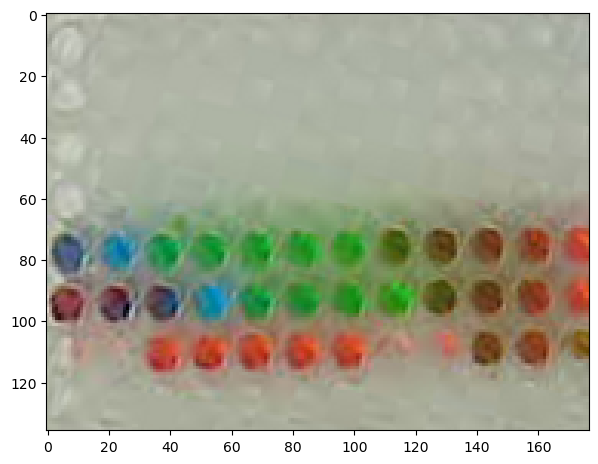

In [10]:
crop_box = final_crop  # (left, upper, right, lower)

left, upper, right, lower = crop_box
image_cropped = img_corr[upper:lower, left:right]

# Create figure and axes
fig, ax = plt.subplots(1, figsize=(7, 7))

# Display the image
ax.imshow(cv2.cvtColor(image_cropped, cv2.COLOR_BGR2RGB))
plt.show()

## Part 10: ROI Extraction and Analysis

### Extract Individual Well Regions

Define functions to slice the plate image into individual well regions and visualize the results with bounding boxes.


In [11]:
import matplotlib.patches as patches

def get_image_array(image, crop_box):
    """Crop an OpenCV image and return width, height, and RGB pixel array."""
    
    left, upper, right, lower = crop_box
    image = image[upper:lower, left:right]

    height, width = image.shape[:2]

    # OpenCV BGR -> RGB to preserve original PIL behavior
    pixel_values = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return width, height, pixel_values


def image_slicing(image_array, col_num, row_num, offset_array):
    """Slice the ROIs from an image array of samples/colorcard."""
    
    row_h = int(np.round(image_array.shape[0] / row_num))
    col_w = int(np.round(image_array.shape[1] / col_num))
    
    fig, ax = plt.subplots(1, figsize=(8, 8))
    
    images = []
    imagecol = []

    for y in np.arange(row_num):
        imagerow = []

        for x in np.arange(col_num):
            # Slicing indices for each color square
            y1 = row_h * y + offset_array[1][0]
            y2 = row_h * (y + 1) - offset_array[1][1]
            x1 = col_w * x + offset_array[0][0]
            x2 = col_w * (x + 1) - offset_array[0][1]

            image = image_array[y1:y2, x1:x2]

            imagerow.append(image)
            images.append(image)

            # Add rectangular patch to axes
            lw = 1
            ec = 'r'
            fc = 'none'

            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=lw, edgecolor=ec, facecolor=fc)
            ax.add_patch(rect)

        imagecol.append(np.concatenate(imagerow, axis=1))

    image_reconstr = np.array(np.concatenate(imagecol, axis=0), dtype=np.uint8)

    return [fig, ax, image_reconstr, images]

## Part 11: Data Visualization - Bar Chart Analysis

### Creating Comprehensive Visualizations

This section creates a bar chart showing RGB values for all wells:

#### **Visualization Features:**
- **Separate bars** for Red, Green, and Blue channels
- **Color-coded bars** (red, green, blue) for easy identification
- **All 96 wells displayed** in a single comprehensive chart
- **Rotated labels** for better readability




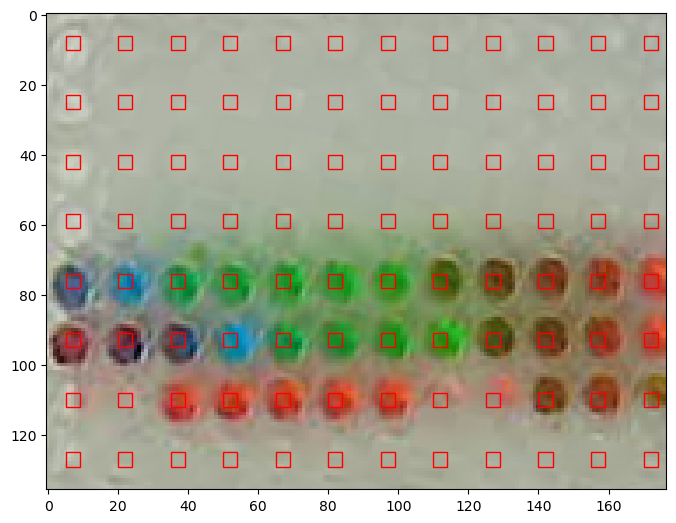

In [12]:
w, h, image_array = get_image_array(img_corr, crop_box)

# Row, Columns Settings and Offset pixels for each sample (TO BE CHANGED)
row_num = 8
col_num = 12
offset_array = [[5, 6], [6, 7]]  # [[x_left, x_right], [y_upper, y_lower]]

#-------------------------------------------------------------------------#

fig_ROI, ax_ROI, reconstr_ROI, image_ROI = image_slicing(image_array, col_num, row_num, offset_array)

# Display original cropped image with ROI boxes
ax_ROI.imshow(image_array)

# Save figure
fig_ROI.savefig(os.path.join(pic_folder, "reconstructed_with_boxes.jpg"))

plt.show()

In [13]:
print(image_ROI)

[array([[[192, 195, 184],
        [193, 196, 184],
        [199, 201, 190],
        [201, 204, 192]],

       [[191, 194, 183],
        [187, 190, 180],
        [191, 194, 183],
        [197, 200, 190]],

       [[184, 187, 176],
        [189, 192, 181],
        [197, 200, 189],
        [200, 203, 192]],

       [[182, 185, 174],
        [193, 196, 185],
        [203, 206, 195],
        [200, 203, 192]]]), array([[[181, 184, 170],
        [179, 183, 169],
        [178, 182, 168],
        [177, 181, 167]],

       [[178, 182, 168],
        [179, 183, 169],
        [179, 183, 169],
        [179, 183, 169]],

       [[177, 181, 167],
        [177, 181, 167],
        [177, 181, 167],
        [178, 182, 168]],

       [[177, 181, 167],
        [177, 181, 167],
        [177, 181, 167],
        [177, 181, 167]]]), array([[[170, 174, 160],
        [171, 175, 161],
        [172, 176, 162],
        [174, 178, 164]],

       [[170, 174, 160],
        [171, 175, 161],
        [173, 177, 163],
    

## Part 12: ROI RGB extraction and well naming (A1 bottom-right)

This section computes the mean RGB for every ROI returned by `image_slicing` as `image_ROI`, assigns well names where the bottom-right well is `A1`, columns increase right→left, rows increase bottom→top (`A..H`), and produces a bar plot labeled by well names.


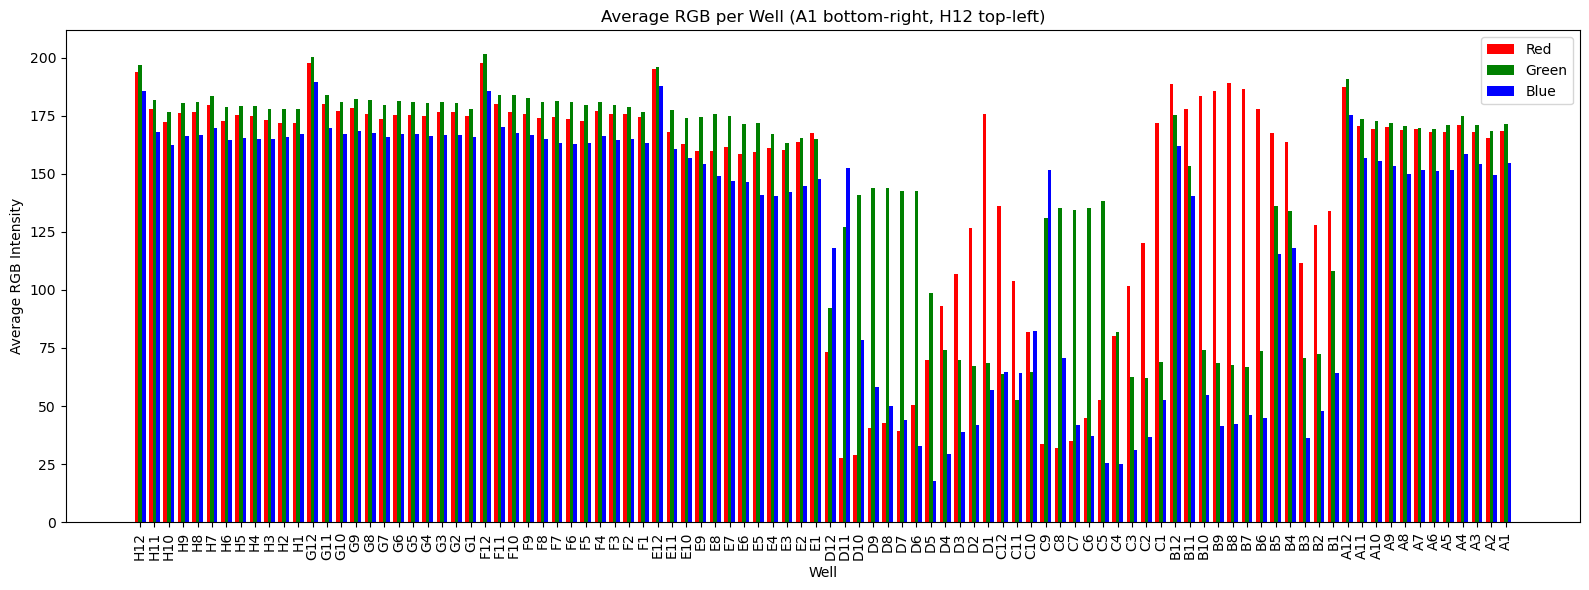

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# image_ROI is a list of numpy arrays from Part 12 (shape ~ [h,w,3])
# Map wells so that:
# - bottom-right is A1
# - bottom second-right is A2
# - second last row right is B1
# - top-left is H12
# image_slicing produced ROIs row-major from top-left to bottom-right:
#   row index y: 0..7 (top..bottom), col index x: 0..11 (left..right)
# We'll compute index -> (row, col) -> well name per the requested orientation.

rows = 8
cols = 12
row_letters = list("ABCDEFGH")  # A..H

# Compute average RGBs and build well names in requested orientation
avg_rgbs = []
well_names = []

for idx, roi in enumerate(image_ROI):
    y = idx // cols            # 0 top .. 7 bottom
    x = idx % cols             # 0 left .. 11 right

    # Requested orientation mapping
    row_letter = row_letters[(rows - 1) - y]     # bottom->top maps to A..H
    col_number = (cols - x)                      # right->left maps to 1..12

    well_name = f"{row_letter}{col_number}"
    well_names.append(well_name)

    rgb_avg = np.mean(np.array(roi), axis=(0, 1))  # [R,G,B]
    avg_rgbs.append(rgb_avg)

avg_rgbs = np.array(avg_rgbs)
r_vals = avg_rgbs[:, 0]
g_vals = avg_rgbs[:, 1]
b_vals = avg_rgbs[:, 2]

# Bar plot labeled with well names
x = np.arange(len(image_ROI))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, r_vals, width, color='red', label='Red')
ax.bar(x,         g_vals, width, color='green', label='Green')
ax.bar(x + width, b_vals, width, color='blue', label='Blue')

ax.set_xlabel("Well")
ax.set_ylabel("Average RGB Intensity")
ax.set_title("Average RGB per Well (A1 bottom-right, H12 top-left)")
ax.set_xticks(x)
ax.set_xticklabels(well_names, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

# For convenience, also expose a dict mapping well -> RGB
well_to_rgb = {name: avg_rgbs[i].tolist() for i, name in enumerate(well_names)}


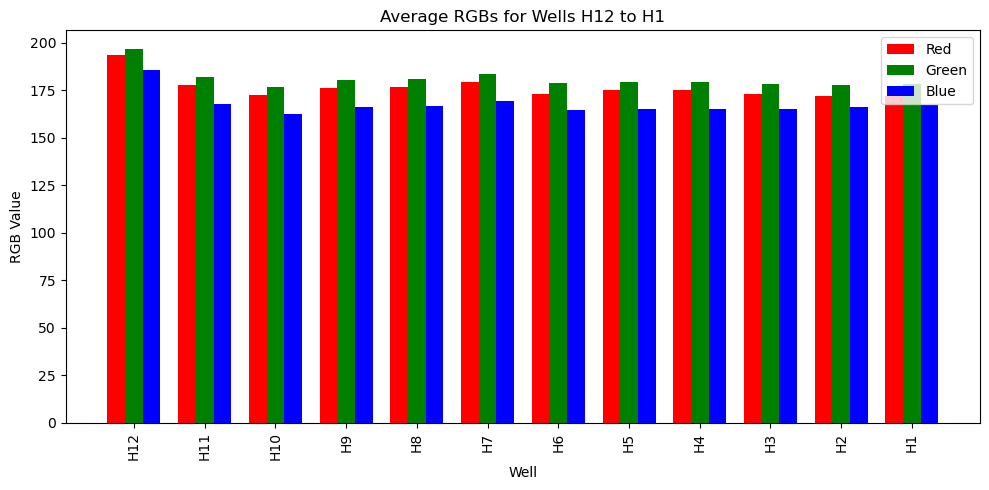

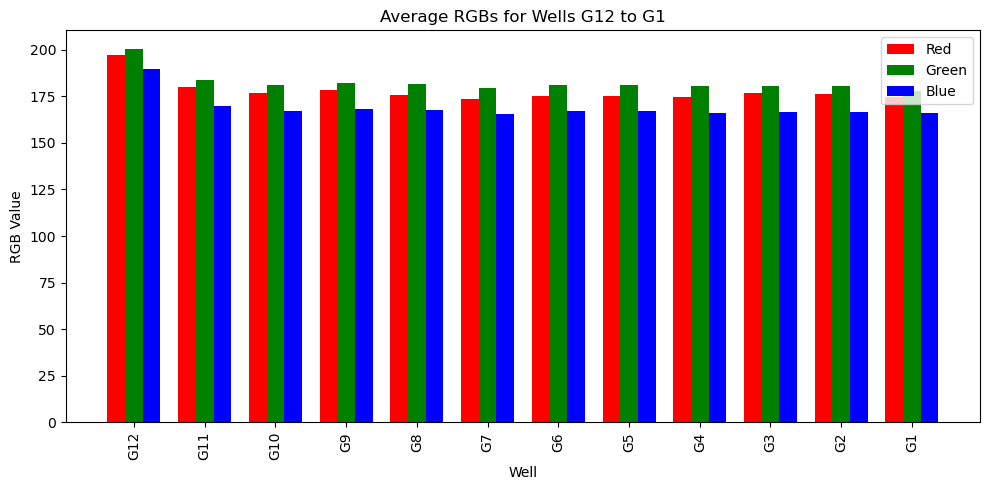

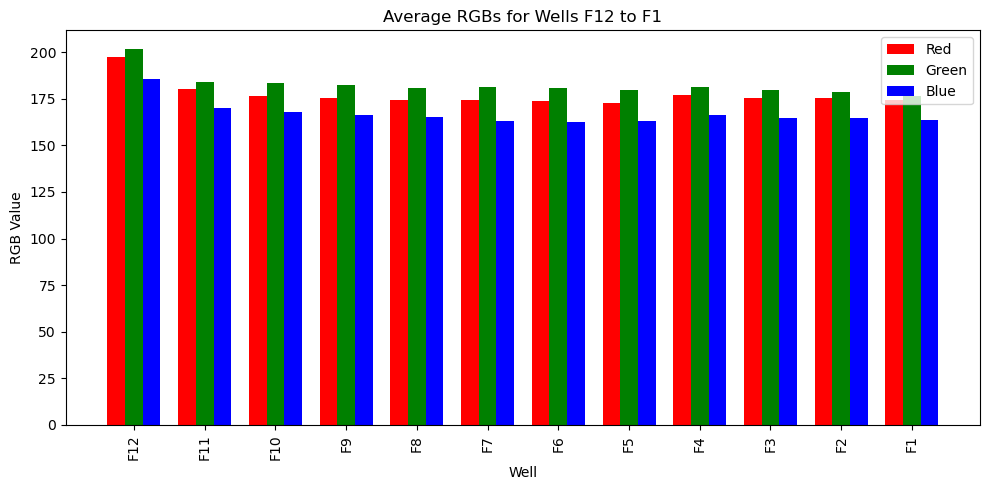

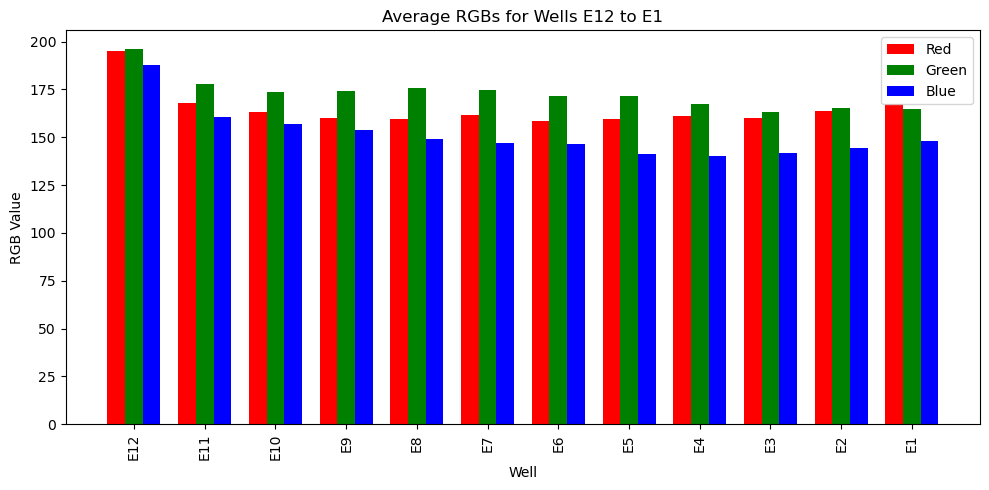

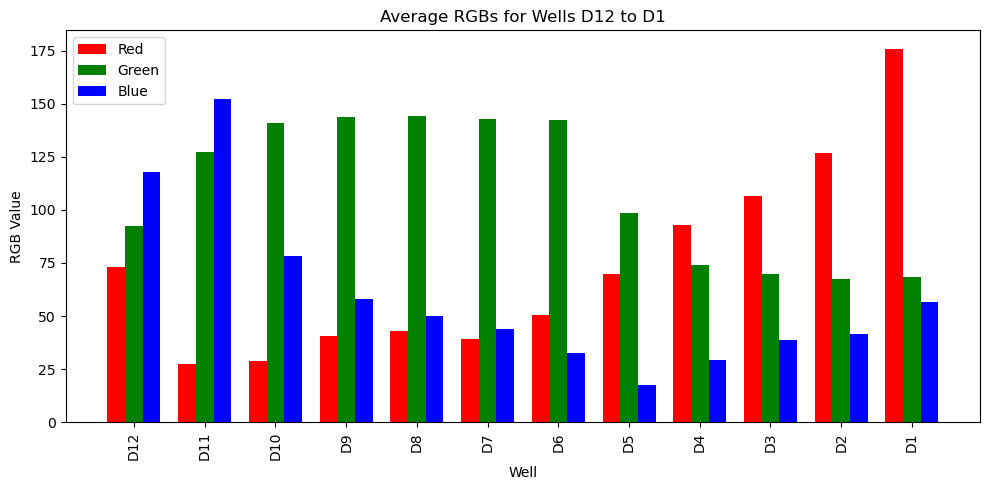

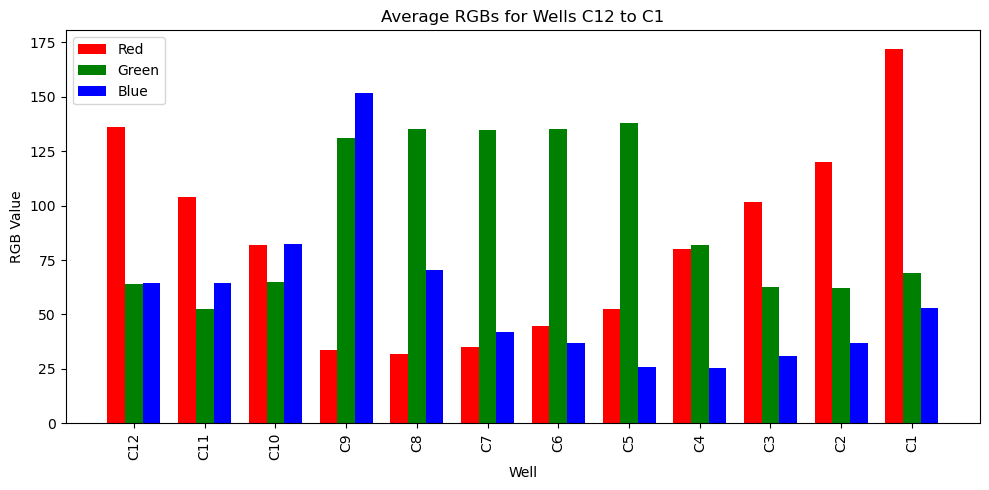

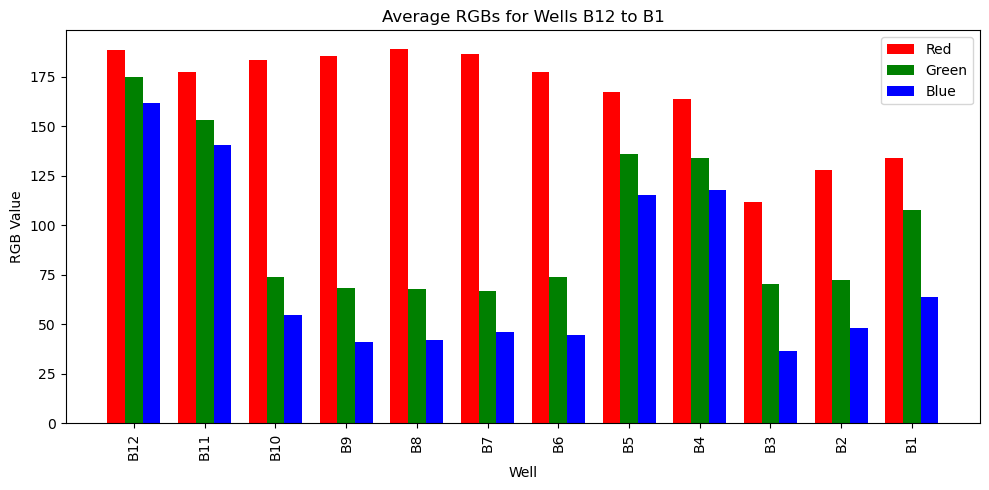

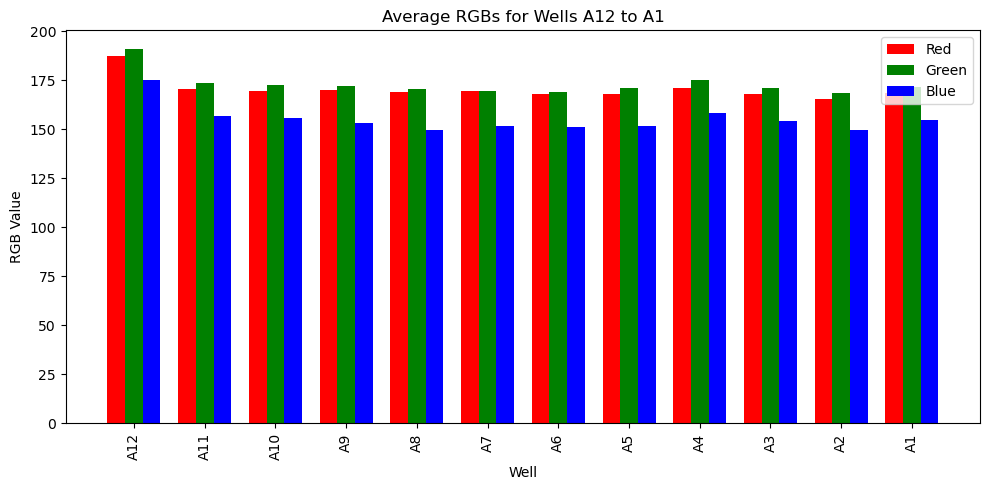

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Use avg_rgbs and well_names computed in the previous cell (Part 12b)
# avg_rgbs: numpy array of shape (96, 3)
# well_names: list of 96 strings like ["A1", ..., "H12"] according to requested orientation

# --- Plot in chunks for readability ---
def plot_rgb_chunks(avg_rgbs, well_names, chunk_size=10):
    num_chunks = int(np.ceil(len(avg_rgbs) / chunk_size))

    for c in range(num_chunks):
        start = c * chunk_size
        end = min((c + 1) * chunk_size, len(avg_rgbs))
        chunk = avg_rgbs[start:end]
        labels = well_names[start:end]

        r_vals = chunk[:, 0]
        g_vals = chunk[:, 1]
        b_vals = chunk[:, 2]
        x = np.arange(len(chunk))
        width = 0.25

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(x - width, r_vals, width, color='red', label='Red')
        ax.bar(x,         g_vals, width, color='green', label='Green')
        ax.bar(x + width, b_vals, width, color='blue', label='Blue')

        ax.set_title(f"Average RGBs for Wells {labels[0]} to {labels[-1]}")
        ax.set_xlabel("Well")
        ax.set_ylabel("RGB Value")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90)
        ax.legend()
        plt.tight_layout()
        plt.show()

# --- Call the function with labeled wells ---
plot_rgb_chunks(avg_rgbs, well_names, chunk_size=12)
